In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Code only in transformer model

Epoch [1/200] - Train Loss: 0.6824, Test Loss: 0.8694, Accuracy: 0.5563, Latency: 0.419s
Epoch [2/200] - Train Loss: 0.6766, Test Loss: 0.8716, Accuracy: 0.6625, Latency: 0.366s
Epoch [3/200] - Train Loss: 0.6431, Test Loss: 0.7943, Accuracy: 0.6687, Latency: 0.387s
Epoch [4/200] - Train Loss: 0.6428, Test Loss: 0.7661, Accuracy: 0.5813, Latency: 0.367s
Epoch [5/200] - Train Loss: 0.6454, Test Loss: 0.7848, Accuracy: 0.6375, Latency: 0.369s
Epoch [6/200] - Train Loss: 0.6354, Test Loss: 0.7868, Accuracy: 0.6500, Latency: 0.382s
Epoch [7/200] - Train Loss: 0.6202, Test Loss: 0.8212, Accuracy: 0.6438, Latency: 0.361s
Epoch [8/200] - Train Loss: 0.6301, Test Loss: 0.8519, Accuracy: 0.6625, Latency: 0.366s
Epoch [9/200] - Train Loss: 0.6272, Test Loss: 0.8328, Accuracy: 0.6562, Latency: 0.376s
Epoch [10/200] - Train Loss: 0.6155, Test Loss: 0.7926, Accuracy: 0.6500, Latency: 0.367s
Epoch [11/200] - Train Loss: 0.6160, Test Loss: 0.7789, Accuracy: 0.6562, Latency: 0.404s
Epoch [12/200] - Tr

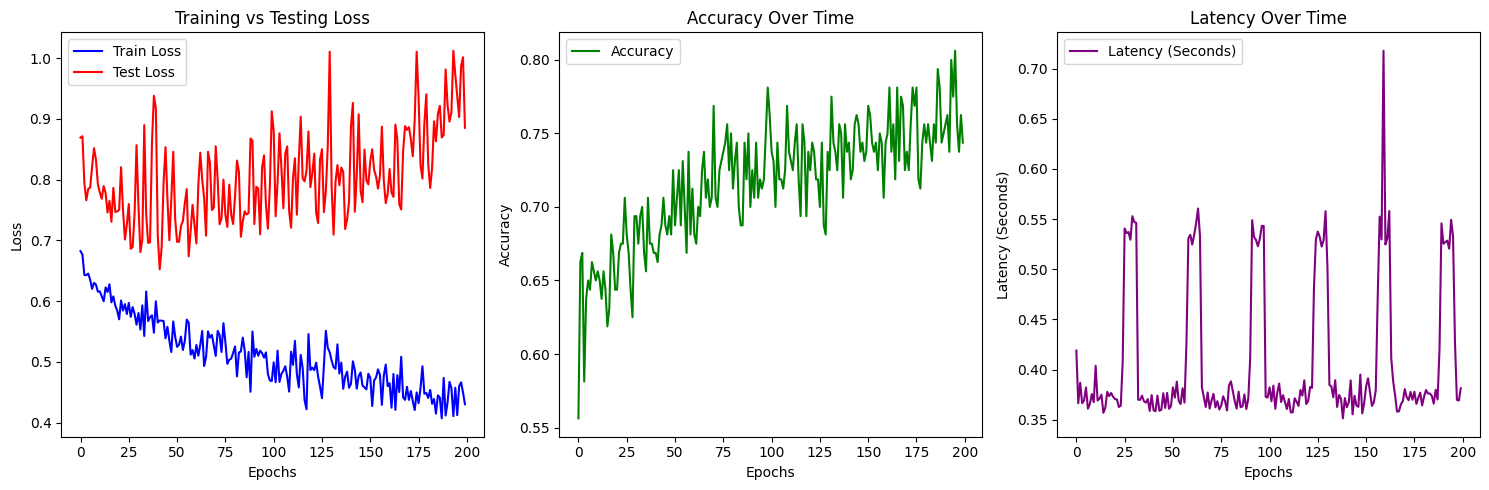

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load datasets
pressure_data = pd.read_csv("/content/drive/MyDrive/Copy of artificial_pressure_data_500.csv")
tectonics_data = pd.read_csv("/content/drive/MyDrive/Tectonic.csv")
gwl_data = pd.read_csv("/content/drive/MyDrive/gwl-monthly.csv")

# Feature selection
pressure_features = ['Pressure (Pa)', 'Signal']
tectonics_features = ['lat', 'lon']
gwl_features = ['WSE']

data = pd.concat([pressure_data[pressure_features], tectonics_data[tectonics_features], gwl_data[gwl_features]], axis=1)
data.dropna(inplace=True)

# Convert target to binary
threshold = 1.0
Y_binary = (data['WSE'] > threshold).astype(int)

# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(data.iloc[:, :-1])
Y = Y_binary

# Apply PCA
pca = PCA(n_components=4)
X_fused = pca.fit_transform(X)

# Convert to tensors
X_tensor = torch.tensor(X_fused, dtype=torch.float32)
Y_tensor = torch.tensor(Y.values, dtype=torch.float32).unsqueeze(1)

# Reshape input tensor
X_tensor = X_tensor.view(X_tensor.shape[0], 1, -1).to(device)
Y_tensor = Y_tensor.to(device)

# Split data
train_size = int(0.8 * len(X_tensor))
test_size = len(X_tensor) - train_size
train_dataset, test_dataset = random_split(TensorDataset(X_tensor, Y_tensor), [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Transformer Model
class TransformerBinary(nn.Module):
    def __init__(self, input_dim, d_model=256, nhead=8, num_layers=6, dropout=0.2):
        super(TransformerBinary, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return self.fc(x)

# Initialize Model
input_dim = X_tensor.shape[2]
model = TransformerBinary(input_dim).to(device)

# Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
num_epochs = 200
train_losses, test_losses, accuracies, latencies = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    start_time = time.time()
    running_loss, correct_preds, total_preds = 0.0, 0, 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct_preds += (Y_pred.round() == Y_batch).sum().item()
        total_preds += Y_batch.size(0)

    epoch_latency = time.time() - start_time
    latencies.append(epoch_latency)
    train_losses.append(running_loss / len(train_loader))
    accuracies.append(correct_preds / total_preds)

    # Test Loss & Accuracy
    model.eval()
    test_loss, correct_preds, total_preds = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            Y_pred_batch = model(X_batch)
            test_loss += criterion(Y_pred_batch, Y_batch).item()
            correct_preds += (Y_pred_batch.round() == Y_batch).sum().item()
            total_preds += Y_batch.size(0)

    test_losses.append(test_loss / len(test_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, Accuracy: {accuracies[-1]:.4f}, Latency: {epoch_latency:.3f}s")

# Evaluation after training
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        Y_pred_batch = model(X_batch).cpu().numpy()
        Y_pred_labels = (Y_pred_batch > 0.5).astype(int)  # Convert probabilities to binary predictions
        all_preds.extend(Y_pred_labels.flatten())
        all_labels.extend(Y_batch.cpu().numpy().flatten())

# Calculate evaluation metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

# Print evaluation results
print("\nModel Evaluation on Test Data:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Time")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(latencies, label="Latency (Seconds)", color='purple')
plt.xlabel("Epochs")
plt.ylabel("Latency (Seconds)")
plt.title("Latency Over Time")
plt.legend()

plt.tight_layout()
plt.show()


Code only in Lstm model

Epoch [1/200] - Train Loss: 0.6928, Test Loss: 0.6872, Accuracy: 0.5400, Latency: 0.036s
Epoch [2/200] - Train Loss: 0.6910, Test Loss: 0.6869, Accuracy: 0.5400, Latency: 0.030s
Epoch [3/200] - Train Loss: 0.6918, Test Loss: 0.6866, Accuracy: 0.5400, Latency: 0.048s
Epoch [4/200] - Train Loss: 0.6916, Test Loss: 0.6862, Accuracy: 0.5400, Latency: 0.032s
Epoch [5/200] - Train Loss: 0.6910, Test Loss: 0.6859, Accuracy: 0.5400, Latency: 0.025s
Epoch [6/200] - Train Loss: 0.6902, Test Loss: 0.6856, Accuracy: 0.5300, Latency: 0.050s
Epoch [7/200] - Train Loss: 0.6910, Test Loss: 0.6852, Accuracy: 0.5400, Latency: 0.060s
Epoch [8/200] - Train Loss: 0.6896, Test Loss: 0.6849, Accuracy: 0.5400, Latency: 0.028s
Epoch [9/200] - Train Loss: 0.6906, Test Loss: 0.6845, Accuracy: 0.5400, Latency: 0.026s
Epoch [10/200] - Train Loss: 0.6914, Test Loss: 0.6842, Accuracy: 0.5400, Latency: 0.026s
Epoch [11/200] - Train Loss: 0.6898, Test Loss: 0.6838, Accuracy: 0.5400, Latency: 0.047s
Epoch [12/200] - Tr

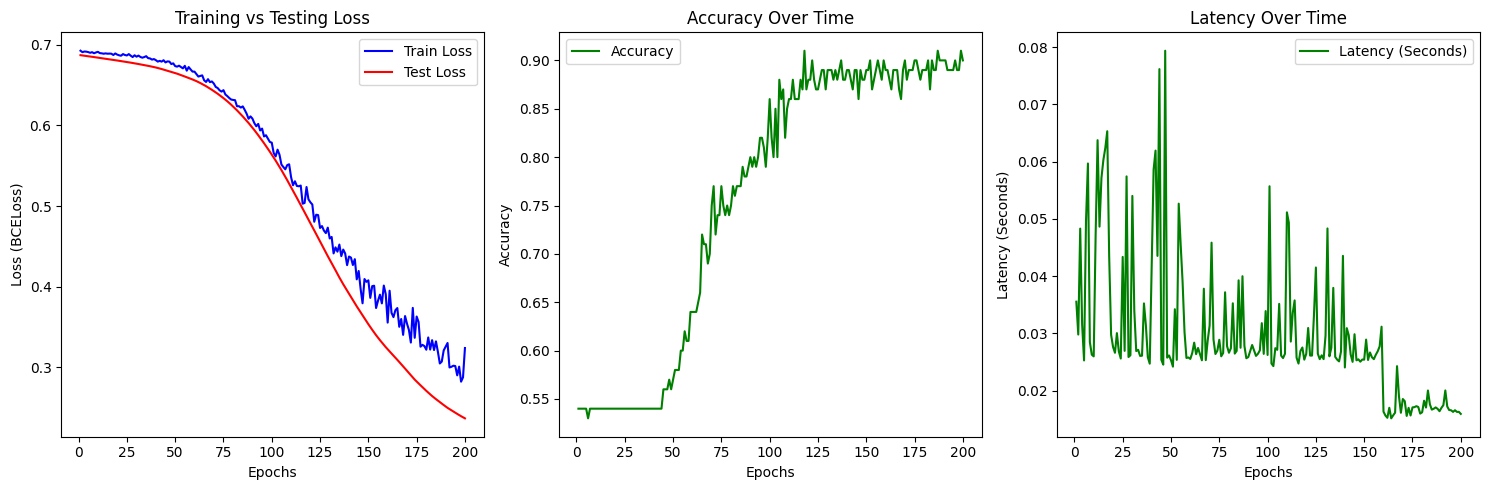

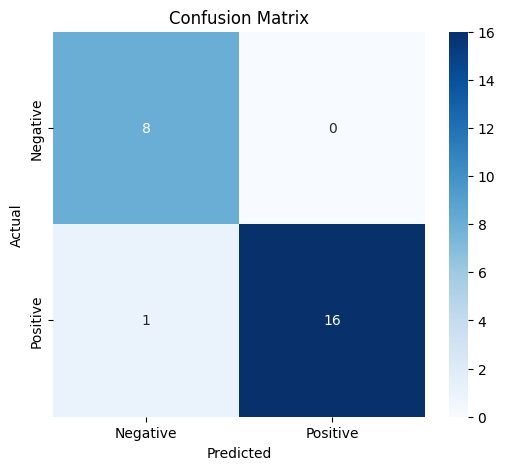

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load datasets
pressure_data = pd.read_csv("/content/drive/MyDrive/Copy of artificial_pressure_data_500.csv")
tectonics_data = pd.read_csv("/content/drive/MyDrive/Tectonic.csv")
gwl_data = pd.read_csv("/content/drive/MyDrive/gwl-monthly.csv")

# Define features
pressure_features = ['Pressure (Pa)', 'Signal']
tectonics_features = ['lat', 'lon']
gwl_features = ['WSE']

# Select relevant columns
pressure_data = pressure_data[pressure_features]
tectonics_data = tectonics_data[tectonics_features]
gwl_data = gwl_data[gwl_features]

# Feature Engineering: Add past WSE values as input features
gwl_data["WSE_lag1"] = gwl_data["WSE"].shift(1)
gwl_data["WSE_lag2"] = gwl_data["WSE"].shift(2)
gwl_data["WSE_lag3"] = gwl_data["WSE"].shift(3)
gwl_data.dropna(inplace=True)

# Merge datasets
data = pd.concat([pressure_data, tectonics_data, gwl_data], axis=1)
data.dropna(inplace=True)

# Convert target to binary (0 or 1) based on a threshold
threshold = 1.0
Y_binary = (data['WSE'] > threshold).astype(int)

# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(data.iloc[:, :-1])
Y = Y_binary

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y.values, dtype=torch.float32).unsqueeze(1)
X_tensor = X_tensor.view(X_tensor.shape[0], 1, -1).to(device)
Y_tensor = Y_tensor.to(device)

# Split data into train & test sets
train_size = int(0.8 * len(X_tensor))
test_size = len(X_tensor) - train_size
train_dataset, test_dataset = random_split(TensorDataset(X_tensor, Y_tensor), [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# LSTM Model for Binary Classification
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]
        return self.fc(x)

# Initialize Model
input_dim = X_tensor.shape[2]
model = LSTMModel(input_dim).to(device)

# Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
num_epochs = 200
train_losses, test_losses, accuracies, latencies = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct_preds, total_preds = 0, 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predicted_classes = (Y_pred > 0.5).float()
        correct_preds += (predicted_classes == Y_batch).sum().item()
        total_preds += Y_batch.size(0)

    train_losses.append(running_loss / len(train_loader))
    accuracies.append(correct_preds / total_preds)
    latencies.append(time.time() - start_time)

    # Test Loss & Accuracy Calculation
    model.eval()
    test_loss, correct_preds, total_preds = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            Y_pred_batch = model(X_batch)
            loss = criterion(Y_pred_batch, Y_batch)
            test_loss += loss.item()
            predicted_classes = (Y_pred_batch > 0.5).float()
            correct_preds += (predicted_classes == Y_batch).sum().item()
            total_preds += Y_batch.size(0)

    test_losses.append(test_loss / len(test_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, Accuracy: {accuracies[-1]:.4f}, Latency: {latencies[-1]:.3f}s")

# Model Evaluation
model.eval()
Y_actuals = []
Y_predictions = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        Y_pred = model(X_batch)
        Y_actuals.extend(Y_batch.cpu().numpy())
        Y_predictions.extend((Y_pred > 0.5).float().cpu().numpy())

# Convert lists to NumPy arrays
Y_actuals = np.array(Y_actuals).flatten()
Y_predictions = np.array(Y_predictions).flatten()

# Calculate Metrics
precision = precision_score(Y_actuals, Y_predictions)
recall = recall_score(Y_actuals, Y_predictions)
f1 = f1_score(Y_actuals, Y_predictions)
conf_matrix = confusion_matrix(Y_actuals, Y_predictions)

# Print Evaluation Results
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f"✅ F1 Score: {f1:.4f}")

# Plot Loss, Accuracy & Latency
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", color='blue')
plt.plot(range(1, num_epochs + 1), test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss (BCELoss)")
plt.title("Training vs Testing Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label="Accuracy", color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Time")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), latencies, label="Latency (Seconds)", color='green')
plt.xlabel("Epochs")
plt.ylabel("Latency (Seconds)")
plt.title("Latency Over Time")
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


PCA with Transformer+LSTM

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch [1/200] - Train Loss: 0.6858, Test Loss: 0.6321, Accuracy: 0.6800, Latency: 0.185s
Epoch [2/200] - Train Loss: 0.6518, Test Loss: 0.5925, Accuracy: 0.6000, Latency: 0.169s
Epoch [3/200] - Train Loss: 0.6314, Test Loss: 0.5308, Accuracy: 0.8400, Latency: 0.156s
Epoch [4/200] - Train Loss: 0.5608, Test Loss: 0.4854, Accuracy: 0.7600, Latency: 0.154s
Epoch [5/200] - Train Loss: 0.5105, Test Loss: 0.4462, Accuracy: 0.7600, Latency: 0.163s
Epoch [6/200] - Train Loss: 0.4511, Test Loss: 0.4057, Accuracy: 0.8000, Latency: 0.147s
Epoch [7/200] - Train Loss: 0.4429, Test Loss: 0.4574, Accuracy: 0.8000, Latency: 0.150s
Epoch [8/200] - Train Loss: 0.3599, Test Loss: 0.4339, Accuracy: 0.8400, Latency: 0.159s
Epoch [9/200] - Train Loss: 0.3463, Test Loss: 0.3700, Accuracy: 0.8400, Latency: 0.168s
Epoch [10/200] - Train Loss: 0.3960, Test Loss: 0.4297, Accuracy: 0.8400, Latency: 0.160s
Epoch [11/200] - Train Loss: 0.3095, Test Loss: 0.4900, Accuracy: 0.8400, Latency: 0.155s
Epoch [12/200] - Tr

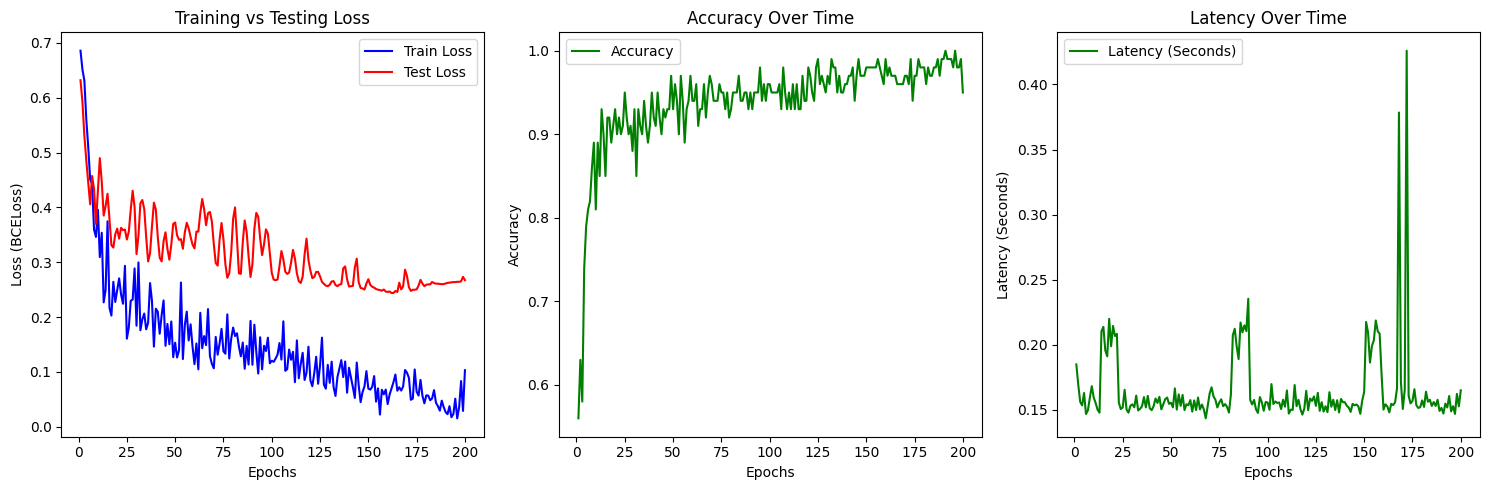

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load datasets
pressure_data = pd.read_csv("/content/drive/MyDrive/Copy of artificial_pressure_data_500.csv")
tectonics_data = pd.read_csv("/content/drive/MyDrive/Tectonic.csv")
gwl_data = pd.read_csv("/content/drive/MyDrive/gwl-monthly.csv")

# Define features
pressure_features = ['Pressure (Pa)', 'Signal']
tectonics_features = ['lat', 'lon']
gwl_features = ['WSE']

# Select relevant columns
pressure_data = pressure_data[pressure_features]
tectonics_data = tectonics_data[tectonics_features]
gwl_data = gwl_data[gwl_features]

# Feature Engineering: Add past WSE values as input features
gwl_data["WSE_lag1"] = gwl_data["WSE"].shift(1)
gwl_data["WSE_lag2"] = gwl_data["WSE"].shift(2)
gwl_data["WSE_lag3"] = gwl_data["WSE"].shift(3)
gwl_data.dropna(inplace=True)  # Remove rows with NaN values due to shifting

# Merge datasets
data = pd.concat([pressure_data, tectonics_data, gwl_data], axis=1)
data.dropna(inplace=True)

# Convert target to binary (0 or 1) based on a threshold
threshold = 1.0  # Example threshold for WSE
Y_binary = (data['WSE'] > threshold).astype(int)  # 1 for Earthquake, 0 for No Earthquake

# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(data.iloc[:, :-1])  # All features except target
Y = Y_binary  # Use the binary target

# Apply PCA for Feature Fusion (Reducing dimensions and fusing features)
pca = PCA(n_components=4)  # Reduce to 4 components
X_fused = pca.fit_transform(X)  # Apply PCA to all input features

# Convert to tensors
X_tensor = torch.tensor(X_fused, dtype=torch.float32)

# Convert Y to a NumPy array before converting to tensor
Y_tensor = torch.tensor(Y.values, dtype=torch.float32).unsqueeze(1)  # Ensure Y is a column vector

# Reshape input tensor
X_tensor = X_tensor.view(X_tensor.shape[0], 1, -1).to(device)
Y_tensor = Y_tensor.to(device)

# Split data into train & test sets
train_size = int(0.8 * len(X_tensor))
test_size = len(X_tensor) - train_size
train_dataset, test_dataset = random_split(TensorDataset(X_tensor, Y_tensor), [train_size, test_size])

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Hybrid Model (LSTM + Transformer) for Binary Classification
class HybridLSTMTransformerBinary(nn.Module):
    def __init__(self, input_dim, d_model=256, nhead=8, num_layers=6, dropout=0.2, lstm_hidden_dim=128):
        super(HybridLSTMTransformerBinary, self).__init__()

        # LSTM layers
        self.lstm = nn.LSTM(input_dim, lstm_hidden_dim, batch_first=True, dropout=dropout)

        # Transformer layers
        self.input_proj = nn.Linear(lstm_hidden_dim, d_model)
        self.pos_encoder = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),  # Output one value (probability for binary classification)
            nn.Sigmoid()  # Sigmoid for binary classification (0 or 1)
        )

    def forward(self, x):
        # LSTM processing
        lstm_out, _ = self.lstm(x)

        # Transformer processing
        x = self.input_proj(lstm_out)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        x = x.mean(dim=1)  # Take mean over sequence length
        return self.fc(x)

# Initialize Model
input_dim = X_tensor.shape[2]
model = HybridLSTMTransformerBinary(input_dim).to(device)

# Loss and Optimizer for Binary Classification
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop with Latency Tracking
num_epochs = 200
train_losses = []
test_losses = []
latencies = []
accuracies = []

for epoch in range(num_epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    correct_preds = 0
    total_preds = 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)

        # Convert predictions to 0 or 1 based on threshold (0.5)
        predicted_classes = (Y_pred > 0.5).float()

        # Calculate loss
        loss = criterion(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Calculate accuracy
        correct_preds += (predicted_classes == Y_batch).sum().item()
        total_preds += Y_batch.size(0)

    epoch_latency = time.time() - start_time
    latencies.append(epoch_latency)

    train_losses.append(running_loss / len(train_loader))
    accuracy = correct_preds / total_preds
    accuracies.append(accuracy)

    # Test Loss & Accuracy Calculation
    model.eval()
    test_loss = 0.0
    correct_preds = 0
    total_preds = 0

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            Y_pred_batch = model(X_batch)
            loss = criterion(Y_pred_batch, Y_batch)
            test_loss += loss.item()

            # Convert predictions to 0 or 1
            predicted_classes = (Y_pred_batch > 0.5).float()
            correct_preds += (predicted_classes == Y_batch).sum().item()
            total_preds += Y_batch.size(0)

    test_losses.append(test_loss / len(test_loader))
    test_accuracy = correct_preds / total_preds
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, Accuracy: {test_accuracy:.4f}, Latency: {epoch_latency:.3f}s")

# Evaluate Model with Precision, Recall, F1-score
def evaluate_model(model, test_loader):
    model.eval()
    correct_preds = 0
    total_preds = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            Y_pred_batch = model(X_batch)
            predicted_classes = (Y_pred_batch > 0.5).float()

            # Collect all predictions and true labels for metric calculations
            all_preds.extend(predicted_classes.cpu().numpy())
            all_labels.extend(Y_batch.cpu().numpy())

            # Calculate accuracy
            correct_preds += (predicted_classes == Y_batch).sum().item()
            total_preds += Y_batch.size(0)

    accuracy = correct_preds / total_preds

    # Calculate Precision, Recall, and F1-score
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"✅ Accuracy: {accuracy * 100:.2f}%")
    print(f"✅ Precision: {precision * 100:.2f}%")
    print(f"✅ Recall: {recall * 100:.2f}%")
    print(f"✅ F1-Score: {f1 * 100:.2f}%")

    return accuracy, precision, recall, f1

# Evaluate Model
accuracy, precision, recall, f1 = evaluate_model(model, test_loader)

# Plot Loss, Accuracy & Latency
plt.figure(figsize=(15, 5))

# Training & Testing Loss Plot
plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", color='blue')
plt.plot(range(1, num_epochs + 1), test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss (BCELoss)")
plt.title("Training vs Testing Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label="Accuracy", color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Time")
plt.legend()

# Latency Plot
plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), latencies, label="Latency (Seconds)", color='green')
plt.xlabel("Epochs")
plt.ylabel("Latency (Seconds)")
plt.title("Latency Over Time")
plt.legend()

plt.tight_layout()
plt.show()
